# 반도체 공정 스케줄링 시뮬레이션 - QSPT
## 환경 설정

In [1]:
import os
import simpy
import random
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Noto Sans KR'
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

load_dotenv()

BASE_DATA_PATH = os.getenv('BASE_DATA_PATH', 'data')
PM_HAZARD_THRESHOLD = os.getenv('PM_HAZARD_THRESHOLD', '0.2')
QTIME_URGENCY_FACTOR = os.getenv('QTIME_URGENCY_FACTOR', '1.5')
MACHINE_CHOICE = 'QSPT'
print(f"MACHINE_CHOICE: {MACHINE_CHOICE}")
print(f"QTIME_URGENCY_FACTOR: {QTIME_URGENCY_FACTOR}")
os.environ["MACHINE_CHOICE"] = MACHINE_CHOICE
os.environ["QTIME_URGENCY_FACTOR"] = str(QTIME_URGENCY_FACTOR)

MACHINE_CHOICE: QSPT
QTIME_URGENCY_FACTOR: 0.3


## 모듈 import

In [2]:
from utils import DataLoader, EventLogger
from utils.visualizer import create_gantt_chart
from simulation import Scheduler

## 데이터 로드

In [3]:
data_loader = DataLoader(BASE_DATA_PATH)
data = data_loader.load_all_data()
print("=" * 60)
print("데이터 개요")
print("=" * 60)
print(f"Jobs: {len(data['jobs'])} 개")
print(f"Operations: {len(data['operations'])} 개")
print(f"Machines: {len(data['machines'])} 개")

데이터 개요
Jobs: 10 개
Operations: 35 개
Machines: 8 개


## 시뮬레이션 실행

In [4]:
random.seed(42)

env = simpy.Environment()
event_logger = EventLogger(env)
scheduler = Scheduler(
    env=env,
    data=data,
    event_logger=event_logger,
    pm_hazard_threshold=float(PM_HAZARD_THRESHOLD),
    qtime_urgency_factor=float(QTIME_URGENCY_FACTOR)
)

In [5]:
env.run(until=scheduler.job_chk_process)
fig = create_gantt_chart(
    logs=event_logger.logs,
    max_time=env.now,
    title=f"간트 차트 [{MACHINE_CHOICE}] (Simulation Time: {round(env.now, 3)})")
fig.show()

## KPI 및 통계
### 작업별 통계

In [6]:
scheduler.get_simulation_info()

Job ID: J1	완료 시간: 48.826
Job ID: J2	완료 시간: 40
Job ID: J3	완료 시간: 120
Job ID: J4	완료 시간: 57
Job ID: J5	완료 시간: 107
Job ID: J6	완료 시간: 63
Job ID: J7	완료 시간: 107.602
Job ID: J8	완료 시간: 124
Job ID: J9	완료 시간: 142
Job ID: J10	완료 시간: 99
시뮬레이션 시간: 142
총 작업 수: 10
완료된 작업 수: 10
기한 안에 완료된 작업 수: 10


### op_id별 작업 시작/종료 시간 (qtime violation 검증)

In [7]:
df_logs = pd.DataFrame(event_logger.logs)

df_job_ops = (
    df_logs[(df_logs['resource'] == 'job') & (df_logs['op_id'].notna())]
    .copy()
    [['id', 'op_id', 'event', 'start', 'finish']]
    .rename(columns={'id': 'job_id'})
    .sort_values(['job_id', 'op_id', 'start'])
    .reset_index(drop=True)
)

qtime_map = data['operations'].set_index('op_id')['qtime']
df_job_ops['qtime_limit'] = df_job_ops['op_id'].map(qtime_map)
df_job_ops['start']       = df_job_ops['start'].astype(int)
df_job_ops['finish']      = df_job_ops['finish'].astype(int)
df_job_ops['qtime_limit'] = df_job_ops['qtime_limit'].astype('Int64')

waiting = (
    df_job_ops[df_job_ops['event'] == 'waiting']
    .groupby(['job_id', 'op_id'])['start'].min()
    .reset_index().rename(columns={'start': 'waiting_start'})
)
working = (
    df_job_ops[df_job_ops['event'] == 'working']
    .groupby(['job_id', 'op_id'])['start'].max()
    .reset_index().rename(columns={'start': 'working_start'})
)
qtime_check = waiting.merge(working, on=['job_id', 'op_id'], how='inner')
qtime_check['actual_wait'] = qtime_check['working_start'] - qtime_check['waiting_start']
qtime_check['qtime_limit'] = qtime_check['op_id'].map(qtime_map).astype('Int64')
qtime_check['violation']   = (qtime_check['actual_wait'] - qtime_check['qtime_limit']).clip(lower=0)

df_job_ops['actual_wait'] = pd.NA
df_job_ops['violation']   = pd.NA

first_waiting_idx = (
    df_job_ops[df_job_ops['event'] == 'waiting']
    .groupby(['job_id', 'op_id'])['start']
    .idxmin()
)
tmp = (
    df_job_ops.loc[first_waiting_idx, ['job_id', 'op_id']]
    .merge(qtime_check[['job_id', 'op_id', 'actual_wait', 'violation']],
           on=['job_id', 'op_id'], how='left')
)
df_job_ops.loc[first_waiting_idx.values, 'actual_wait'] = tmp['actual_wait'].values
df_job_ops.loc[first_waiting_idx.values, 'violation']   = tmp['violation'].values

display(df_job_ops)
print("\n--- qtime 위반 상세 ---")
display(qtime_check[qtime_check['violation'] > 0])
print(f"\nQTIME TOTAL: {round(qtime_check['violation'].sum(), 3)}")

,job_id,op_id,event,start,finish,qtime_limit,actual_wait,violation
0,J1,J1_O1,waiting,0,0,<NA>,0,<NA>
1,J1,J1_O1,setup,0,0,<NA>,<NA>,<NA>
2,J1,J1_O1,working,0,8,<NA>,<NA>,<NA>
3,J1,J1_O2,waiting,8,8,20,0,0
4,J1,J1_O2,setup,8,8,20,<NA>,<NA>
5,J1,J1_O2,working,8,23,20,<NA>,<NA>
6,J1,J1_O3,waiting,23,27,12,4,0
7,J1,J1_O3,waiting,27,27,12,<NA>,<NA>
8,J1,J1_O3,setup,27,27,12,<NA>,<NA>
9,J1,J1_O3,working,27,39,12,<NA>,<NA>



--- qtime 위반 상세 ---


,job_id,op_id,waiting_start,working_start,actual_wait,qtime_limit,violation
11,J3,J3_O2,15,57,42,18,24
18,J5,J5_O2,17,55,38,15,23
29,J8,J8_O2,61,84,23,18,5
32,J9,J9_O2,59,85,26,15,11



QTIME TOTAL: 63


### 작업별 소요 시간

,waiting,setup,working,job_type
id,,,,
J1,4.826,0.0,44.000,P1
J3,49.000,3.0,68.000,P1
J5,41.000,7.0,59.000,P1
J7,24.000,5.0,78.602,P1
J9,70.000,0.0,72.000,P1
J10,48.000,4.0,47.000,P2
J2,0.000,0.0,40.000,P2
J4,9.000,5.0,43.000,P2
J6,19.000,4.0,40.000,P2


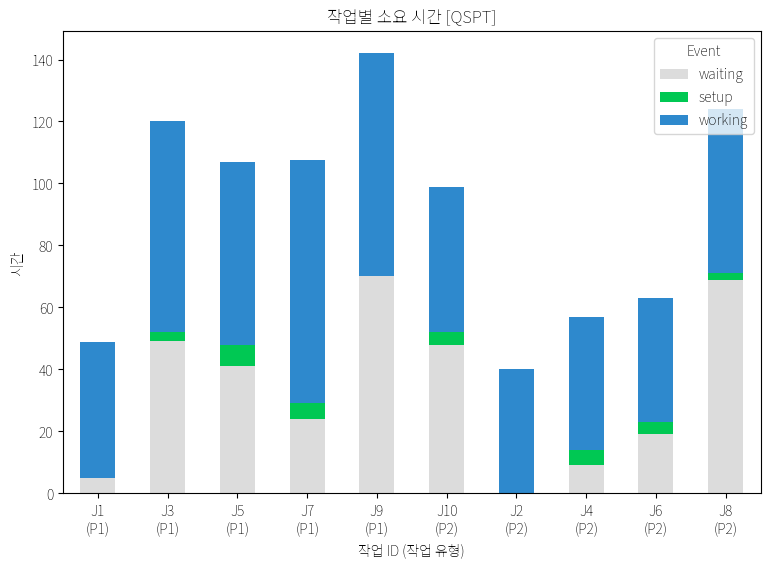

In [8]:
df_logs = pd.DataFrame(event_logger.logs)
job_info = df_logs[df_logs['resource'] == 'job']
job_info['duration'] = round(job_info['finish'] - job_info['start'], 3)
job_info = job_info.groupby(['id', 'event'])['duration'].sum().reset_index()
job_stacked = job_info.pivot(index='id', columns='event', values='duration').fillna(0)
job_stacked = job_stacked.reindex(columns=['waiting', 'setup', 'working'], fill_value=0)
job_type_map = data['jobs'].set_index('job_id')['job_type']
job_stacked = job_stacked.join(job_type_map).sort_values('job_type')
display(job_stacked)
job_stacked.index = [f"{i}\n({t})" for i, t in zip(job_stacked.index, job_stacked['job_type'])]
job_stacked.drop(columns='job_type').plot(kind='bar', stacked=True, figsize=(9, 6), color={
    "waiting": '#DCDCDC',
    "setup": '#00C853',
    "working": '#2E89CD'
})
plt.title(f"작업별 소요 시간 [{MACHINE_CHOICE}]")
plt.xlabel("작업 ID (작업 유형)")
plt.ylabel("시간")
plt.xticks(rotation=0)
plt.legend(title="Event")
plt.show()

### 공정별 설비 활용률

,utilization,group
id,,
M1,0.633803,G1
M2,0.490157,G1
M3,0.478873,G1
M4,0.549296,G2
M5,0.514085,G2
M6,0.394366,G3
M7,0.373239,G3
M8,0.401408,G3


C:\Users\User\AppData\Local\Temp\ipykernel_19172\3634141619.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=machine_utilization, x='group', y='utilization',


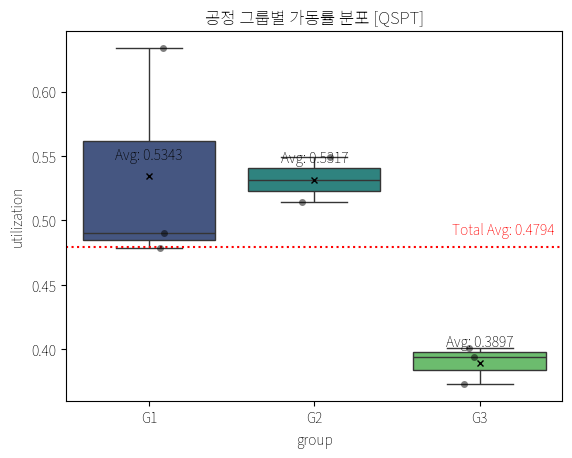

In [9]:
df_logs = pd.DataFrame(event_logger.logs)
machine_info = df_logs[df_logs['resource'] == 'machine']
machine_info['utilization'] = machine_info['finish'] - machine_info['start']
machine_utilization = pd.DataFrame(
    machine_info[machine_info['event'] == 'working'].groupby('id')['utilization'].sum() / env.now
)
machine_utilization['group'] = data['machines'].set_index('machine_id').loc[machine_utilization.index]['machine_group']
display(machine_utilization)

group_means = machine_utilization.groupby('group')['utilization'].mean()
total_mean  = machine_utilization['utilization'].mean()

sns.boxplot(data=machine_utilization, x='group', y='utilization',
            palette='viridis', showmeans=True,
            meanprops={"marker":"x", "markeredgecolor":"black", "markersize":"5"})
sns.stripplot(data=machine_utilization, x='group', y='utilization',
              color='black', alpha=0.5, jitter=True)
for i, group in enumerate(group_means.index):
    mean_val = group_means[group]
    plt.text(i, mean_val + 0.01, f'Avg: {mean_val:.4f}',
             ha='center', va='bottom', color='black', fontweight='bold')
plt.text(len(group_means)-0.55, total_mean + 0.01,
         f'Total Avg: {total_mean:.4f}', color='red', fontweight='bold', ha='right')
plt.axhline(total_mean, color='red', linestyle=':')
plt.title(f"공정 그룹별 가동률 분포 [{MACHINE_CHOICE}]")
plt.show()